https://www.cnblogs.com/starlitnightly/p/18258522  
https://single-cell-tutorial.readthedocs.io/zh/latest/

Normalization
https://www.cnblogs.com/starlitnightly/p/18258580

1.0 导入环境和数据 

In [7]:
# 验证关键依赖是否可用，特别是 torch 和 omicverse
import torch
import scanpy as sc
import omicverse as ov

# # 检查 GPU 加速是否可用
# print("PyTorch CUDA是否可用:", torch.cuda.is_available())

In [8]:
ov.utils.ov_plot_set()

🔬 Starting plot initialization...
🧬 Detecting CUDA devices…
✅ [GPU 0] NVIDIA GeForce RTX 3060 Laptop GPU
    • Total memory: 6.0 GB
    • Compute capability: 8.6
✅ plot_set complete.



1. 我们使用scanpy加载来自Figshare上托管的数据集。该数据可以是你自己的数据，也可以使用ov.utils.pancreas()来获取Bastidas-Ponce et al. (2019)的数据。

In [9]:
adata = sc.read_10x_h5(
    filename="filtered_feature_bc_matrix.h5",
  backup_url="https://figshare.com/ndownloader/files/39546196",
)
#adata=ov.utils.pancreas() # 载入示例数据集 <<<<============== Another good dataset
adata

# 一个标准的 $Scanpy$ 数据对象 (AnnData 对象，通常简称为 adata)，这是单细胞分析的核心数据结构

reading filtered_feature_bc_matrix.h5
 (0:00:04)


AnnData object with n_obs × n_vars = 16934 × 36601
    var: 'gene_ids', 'feature_types', 'genome', 'interval'

In [10]:
adata.var.head()

,gene_ids,feature_types,genome,interval
MIR1302-2HG,ENSG00000243485,Gene Expression,GRCh38,chr1:29553-30267
FAM138A,ENSG00000237613,Gene Expression,GRCh38,chr1:36080-36081
OR4F5,ENSG00000186092,Gene Expression,GRCh38,chr1:65418-69055
AL627309.1,ENSG00000238009,Gene Expression,GRCh38,chr1:120931-133723
AL627309.3,ENSG00000239945,Gene Expression,GRCh38,chr1:91104-91105


In [11]:
adata.var_names_make_unique()
adata.obs_names_make_unique()

我们首先检查原始计数UMI的分布，一般在后续的分析中我们会忽略这一步，但对该分布的认识有利于我们理解归一化的意义。

In [18]:
# 线粒体基因
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# 核糖体基因
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# 血红蛋白基因
adata.var["hb"] = adata.var_names.str.contains(("^HB[^(P)]"))



In [19]:
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, percent_top=[20], log1p=True
)
adata


AnnData object with n_obs × n_vars = 16934 × 36601
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

In [20]:
adata.obs.head()

,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_20_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb
AAACAGCCAAGCTTAT-1,1362,7.217443,2243.0,7.716015,9.719126,18.0,2.944439,0.802497,125.0,4.836282,5.572894,3.0,1.386294,0.133749
AAACAGCCATAGCTTG-1,2126,7.662468,4085.0,8.315322,10.820073,63.0,4.158883,1.542228,69.0,4.248495,1.689106,10.0,2.397895,0.244798
AAACAGCCATGAAATG-1,899,6.802395,3050.0,8.023225,60.557377,56.0,4.043051,1.836066,80.0,4.394449,2.622951,5.0,1.791759,0.163934
AAACAGCCATGTTTGG-1,1340,7.201171,2227.0,7.708859,12.977099,30.0,3.433987,1.347104,42.0,3.761200,1.885945,1.0,0.693147,0.044903
AAACATGCAACGTGCT-1,828,6.720220,1211.0,7.100027,14.037985,20.0,3.044523,1.651528,44.0,3.806663,3.633361,6.0,1.945910,0.495458


我们首先检查原始计数UMI的分布，一般在后续的分析中我们会忽略这一步，但对该分布的认识有利于我们理解归一化的意义。

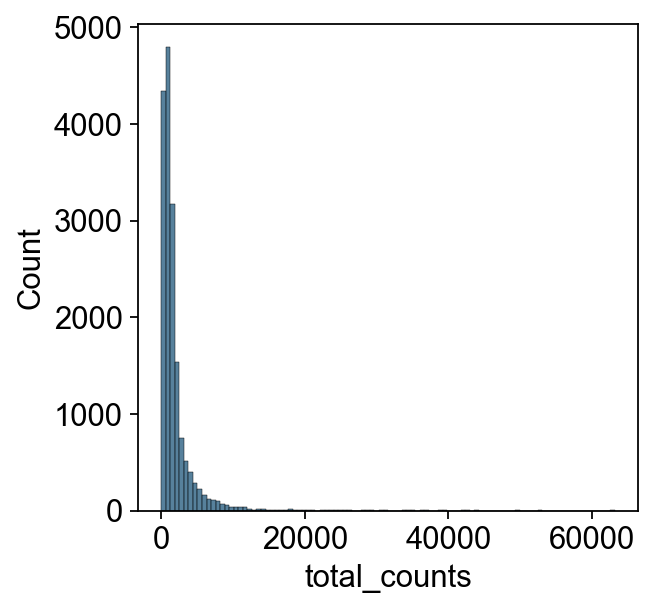

In [22]:
import seaborn as sns
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False)


2. 移位对数
我们将介绍的第一个归一化方法是基于delta方法的移位对数。Delta方法应用非线性函数，使得原始计数中的差异更加相似。

我们定义非线性函数的变换如下：
 
 
其中是原始的计数，是尺寸因子，是伪计数。我们为每一个细胞确定自己的尺寸因子，以满足同时考虑采样效果和不同细胞尺寸的变换。细胞的尺寸因子可以计算为：

 
 
其中 
代表不同的基因，代表基因的计数总和。确定尺寸因子的方法有很多，在scanpy中，我们默认使用原始计数深度的中位数来计算，而在seruat中使用固定值，而在omicverse的预处理中，我们将设定为。不同的值会使得过度离散值不同。

In [23]:
scales_counts = sc.pp.normalize_total(adata, target_sum=None, inplace=False)
# log1p transform
adata.layers["log1p_norm"] = sc.pp.log1p(scales_counts["X"], copy=True)


normalizing counts per cell
    finished (0:00:00)


我们使用hist图来对比归一化前后的计数变化

我们发现nUMI的最大值在1000左右，经过移位对数化后，并且移位对数化后的nUMI的分布近似正态分布。

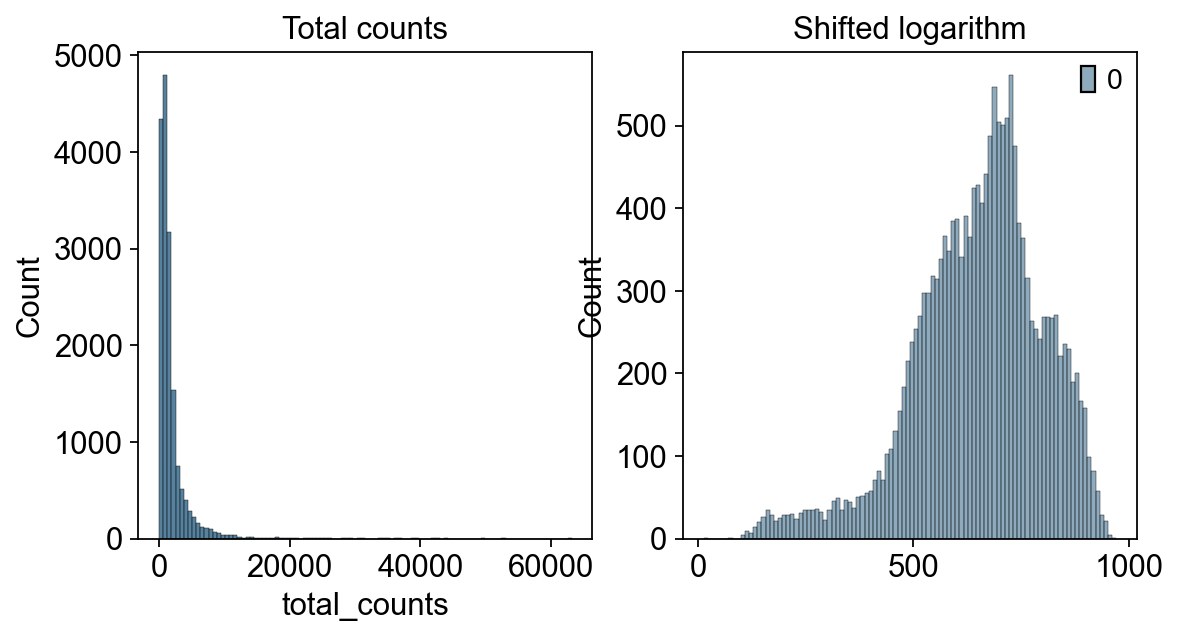

In [ ]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")

p2 = sns.histplot(adata.layers["log1p_norm"].sum(1), bins=100, kde=False, ax=axes[1])
axes[1].set_title("Shifted logarithm")

plt.show()


3. 皮尔森近似残差
我们观察到，scRNA-seq数据中的细胞间变异包括了生物异质性以及技术效应。而移位计数并不能很好的排除两种不同变异来源的混淆误差。皮尔森近似残差利用了“正则化负二项式回归”的皮尔森残差来计算数据中潜在的技术噪音，将计数深度添加为广义线性模型中的协变量，而在不同的归一化方法的测试中，皮尔森残差法可以消除计数效应带来的误差，并且保留了数据集中的细胞异质性。

此外，皮尔森残差法不需要进行启发式步骤，如伪计数加法/对数变化，该方法的输出就是归一化后的值，包括了正值和负值。细胞和基因的负残差表明与基因的平均表达和细胞测序深度相比，观察到的计数少于预期。正残差分别表示计数越多。解析 Pearon 残差在 scanpy 中实现，可以直接在原始计数矩阵上计

In [ ]:
# from scipy.sparse import csr_matrix

# #analytic_pearson = sc.experimental.pp.normalize_pearson_residuals(adata, inplace=True)
# analytic_pearson = sc.experimental.pp.normalize_pearson_residuals(adata, inplace=False) 

# adata.layers["analytic_pearson_residuals"] = csr_matrix(analytic_pearson["X"])


computing analytic Pearson residuals on adata.X
    finished (0:00:21)


In [31]:
import scanpy.experimental as sce

# 确保您已经完成了 QC 过滤，并且 adata.X 仍然是原始计数 (Counts)
print("正在执行皮尔逊残差归一化...")

# 使用实验性模块中的 normalize_pearson_residuals
# 这会将残差计算出来，并存储在 adata.layers["analytic_pearson_residuals"] 中
# 此外，它还会将 adata.X 替换为归一化后的数据 (残差)
sce.pp.normalize_pearson_residuals(
    adata,
    inplace=True # 直接修改 adata，并将残差存储在 layers 中
)

print("归一化完成。残差矩阵已存储在 adata.layers['analytic_pearson_residuals']")
# 此时，adata.layers.keys() 应该包含 'analytic_pearson_residuals'
print(f"当前 layers 键: {adata.layers.keys()}")

正在执行皮尔逊残差归一化...
computing analytic Pearson residuals on adata.X
    finished (0:00:24)
归一化完成。残差矩阵已存储在 adata.layers['analytic_pearson_residuals']
当前 layers 键: KeysView(Layers with keys: log1p_norm, analytic_pearson_residuals)


核心原因： $adata.layers["analytic_pearson_residuals"]$ 是一个稀疏矩阵 ($scipy.sparse$)，当您对其调用 .sum(1) 时，结果是一个一维稀疏数组。$Seaborn$ 的 histplot 函数不能直接处理稀疏数组。在 $Seaborn$ 内部调用 $Pandas$ 的 pd.concat 时，无法将稀疏数据识别为可连接的对象，从而抛出 ValueError。解决办法：将稀疏数组转换为 $NumPy$ 稠密数组您需要确保传入 $Seaborn$ 的数据是一个标准的 $NumPy$ 数组或 $Pandas$ 系列（$Series$）。

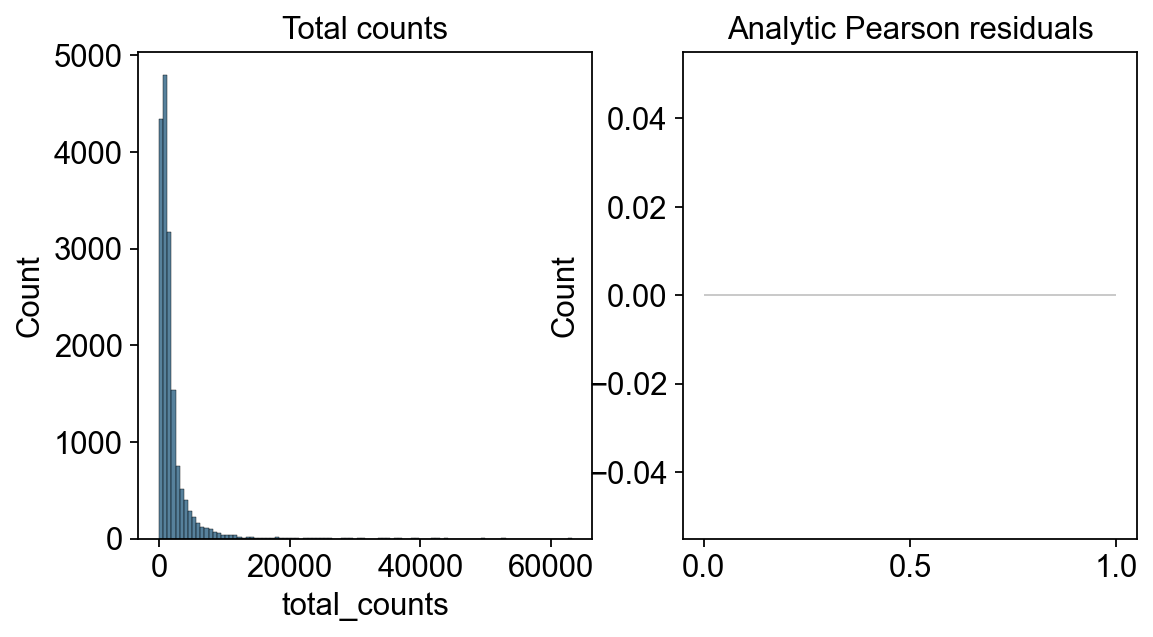

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# 导入 scipy.sparse 可能会有所帮助，但通常不是必须的

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

p1 = sns.histplot(
    adata.obs["total_counts"], bins=100, kde=False, ax=axes[0]
)

axes[0].set_title("Total counts")

# === 关键修复点：将求和结果转换为稠密数组 (.A1) ===
residuals_sum = adata.layers["analytic_pearson_residuals"].sum(1)

# 确保 residual_sum 能够被 seaborn 接受：
# 对于 scipy.sparse 矩阵的求和结果，.A1 可以将其转换为一维 numpy 数组
if hasattr(residuals_sum, 'A1'):
    data_for_plot = residuals_sum.A1
else:
    # 如果不是稀疏矩阵，直接使用
    data_for_plot = residuals_sum


p2 = sns.histplot(
    data_for_plot, 
    bins=100, 
    kde=False, 
    ax=axes[1]
)
# =======================================================

axes[1].set_title("Analytic Pearson residuals")

plt.show()


. 一键式归一化
我们在omicverse中提供了预处理函数pp.preprocess，该方法可直接计算移位对数或皮尔森残差，方法内同时包括了基于移位对数/皮尔森残差的高可变基因的选择方法，高可变基因会在下一节的教程中进行讲解。

此外，我们omicverse的归一化方法还提供了稳定基因的识别与过滤。

4.1 移位对数
在omicverse中，我们设置mode='shiftlog|pearson'即可完成移位对数的计算，一般来说，默认的target_sum=50*1e4，同时高可变基因定义为前2000个,需要注意的是，当omicverse的版本小于1.4.13时，mode的参数只能设置为scanpy或pearson，scanpy与shiftlog的意义是相同的

In [35]:
adata_log=ov.pp.preprocess(adata,mode='shiftlog|pearson',n_HVGs=2000,)
adata_log


Begin robust gene identification
After filtration, 36601/36601 genes are kept.     Among 36601 genes, 36601 genes are robust.
End of robust gene identification.
Begin size normalization: shiftlog and HVGs selection pearson
normalizing counts per cell
The following highly-expressed genes are not considered during normalization factor computation:
[]
    finished (0:00:08)
extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'highly_variable_nbatches', int vector (adata.var)
    'highly_variable_intersection', boolean vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'residual_variances', float vector (adata.var)
Time to analyze data in cpu: 71.57789826393127 seconds.
End of size normalization: shiftlog and HVGs selection pearson


AnnData object with n_obs × n_vars = 16934 × 36601
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'robust', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable_features'
    uns: 'pearson_residuals_normalization', 'log1p', 'hvg', 'status', 'status_args', 'REFERENCE_MANU'
    layers: 'log1p_norm', 'analytic_pearson_residuals', 'counts'

.2 皮尔森近似残差
我们也可以设置mode='pearson|pearson'来完成皮尔森近似残差的计算，此时我们不需要输入target_sum，需要注意的是，当omicverse的版本小于1.4.13时，mode的参数只能设置为scanpy或pearson

In [36]:
adata_pearson=ov.pp.preprocess(adata,mode='pearson|pearson',n_HVGs=2000,)
adata_pearson


Begin robust gene identification
After filtration, 36601/36601 genes are kept.     Among 36601 genes, 36601 genes are robust.
End of robust gene identification.
Begin size normalization: pearson and HVGs selection pearson
computing analytic Pearson residuals on adata.X
    finished (0:00:21)
extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'highly_variable_nbatches', int vector (adata.var)
    'highly_variable_intersection', boolean vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'residual_variances', float vector (adata.var)
Time to analyze data in cpu: 77.55131244659424 seconds.
End of size normalization: pearson and HVGs selection pearson


AnnData object with n_obs × n_vars = 16934 × 36601
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'robust', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable_features'
    uns: 'pearson_residuals_normalization', 'hvg', 'status', 'status_args', 'REFERENCE_MANU'
    layers: 'log1p_norm', 'analytic_pearson_residuals', 'counts'

我们对比一下两种分析的结果

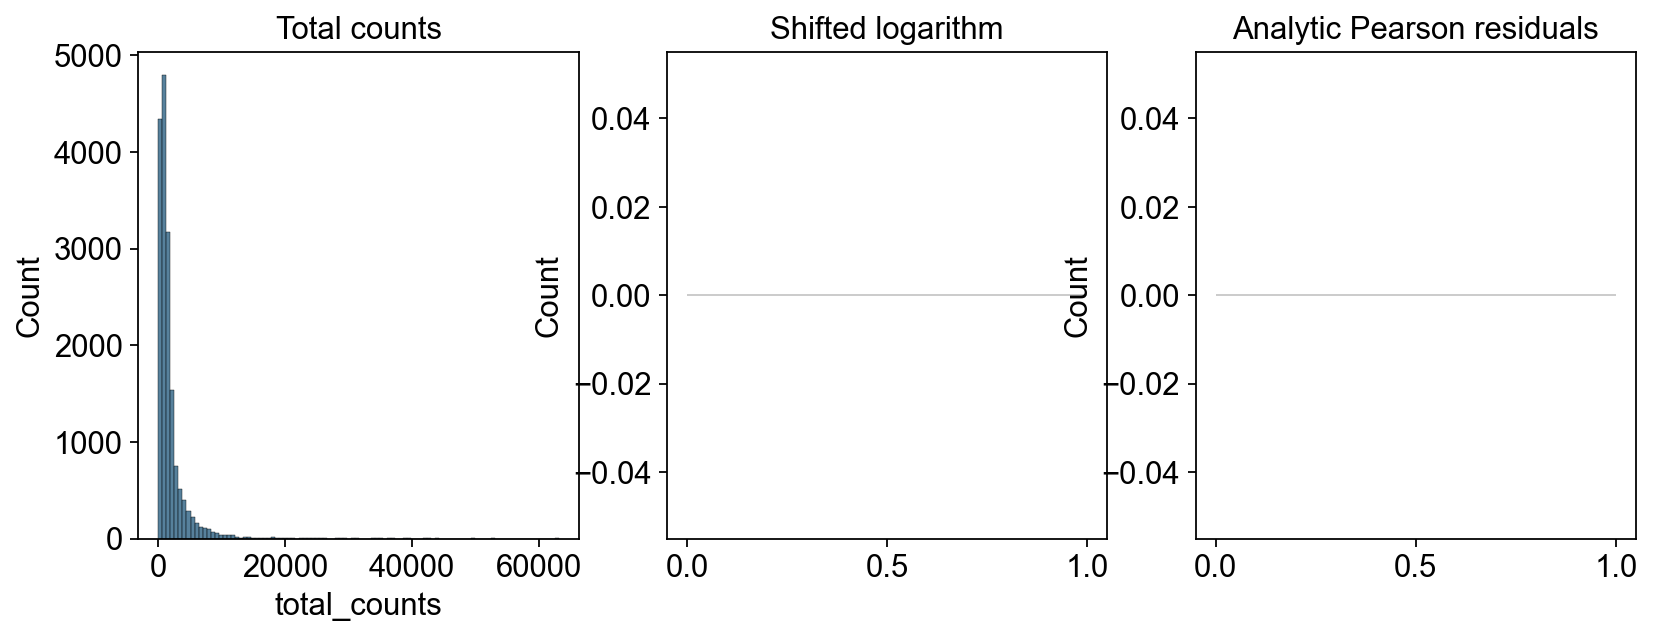

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")

p2 = sns.histplot(
    adata_log.X.sum(1), bins=100, kde=False, ax=axes[1]
)
axes[1].set_title("Shifted logarithm")

p3 = sns.histplot(
    adata_pearson.X.sum(1), bins=100, kde=False, ax=axes[2]
)
axes[2].set_title("Analytic Pearson residuals")
plt.show()


以上，就是本章所要介绍的归一化内容，通过benchmark的测试，我们发现移位对数适用于大多数任务。但是如果我们的分析目标是寻找稀有细胞的时候，可以考虑采用皮尔森残差法来进行归一化。